# **Question 3: Finite difference method - Backwards Euler**

$$F(T,r)=1$$ for all $r\geq0$, together with the partial differential equation
$$\frac{\partial F}{\partial t}(t,r)+a(b-r)\frac{\partial F}{\partial r}(t,r)+\frac{1}{2}\sigma^2 r\frac{\partial^2 F}{\partial r^2}(t,r)-rF(t,r)=0$$ for all $t\in(0,T)$, $r\geq0$. Where $a$, $b$, and $\sigma$ are given parameters.

$F$ follows:

- $F(t,r)\in[0,1]\forall t\in[0,T],r\geq0$
- $r\leq0.5$
- $$\lim_{r\to0}F(t,r)=A(t)\forall t\in[0,T)$$ where $$A(t)=\left[\frac{2\gamma e^{(a+\gamma)t/2}}{(\gamma+a)(e^{\gamma t}-1)+2\gamma}\right]^{\frac{2ab}{\sigma^2}}$$ and $\gamma = \sqrt{a^2+2\sigma^2}$
- $$\lim_{r\to\infty}\left(\frac{\partial F}{\partial r}(t,r)+A(t)B(t)e^{-B(t)r}\right)=0$$ where $$B(t)=\frac{2(e^{\gamma t}-1)}{(\gamma+a)(e^{\gamma t}-1)+2\gamma}$$

See `Part_3.pdf` for iterative scheme and updating this problem to a initial value problem.



In [1]:
# Import packages
import numpy as np
import math
import scipy.sparse as ssparse
import scipy.sparse.linalg as ssla

# Backwards Euler Approximation Function:
def BE_Approx(rmax, T, a, b, sigma, M, N):
  """Approximation of grid points of a given final value problem using
  backwards Euler method.
  Arguments:
    rmax: upper boundary of grid space
    T: maturity date
    a: given parameter
    b: given parameter
    sigma: given parameter
    M: positive integer number of steps in direction s
    N: positive integer number of steps in direction r
  Returns:
    F: matrix of results, F[i,j] is value at
        iT/M and j*rmax/N
    Stable: Boolean indicating method stability
    ts: array of t values used for grid points
    rs: array of r values used at grid points
  """

  G = np.zeros((M+1,N+1))
  gamma = math.sqrt(a**2 + 2*sigma**2)

  # discritization parameters
  s = np.linspace(0, T, M+1)
  r = np.linspace(0, rmax, N+1)
  rint = r[1:-1]
  dr = r[1] - r[0]
  ds = s[1] - s[0]

  rs = r

  # initial condition
  G[0,:] = 1

  # define iterative coefficient functions
  def alpha(r):
    return 1 + ((sigma**2) * r/(dr**2) + r) * ds

  def beta(r):
    return -ds * (sigma**2 * r / (2 * dr**2) - a*(b - r) / (2 * dr))

  def delta(r):
    return -ds * (sigma**2 * r / (2 * dr**2) + a*(b - r) / (2 * dr))

  # define boundary condition functions
  def p(s):
    return ((2*gamma*np.exp((a+gamma)*0.5*(s)))/((gamma + a)*(np.exp(gamma * (s))-1)+2*gamma))**(2*a*b/(sigma**2))

  def l(s):
    return p(s)*np.exp(-((2*(np.exp(gamma*(s))-1))/((gamma+a)*(np.exp(gamma*(s))-1)+2*gamma))*rmax)

  uB = delta(rint)
  dB = alpha(rint)
  lB = beta(rint)

  AB = ssparse.diags_array([dB, uB[:-1], lB[1:]], offsets=[0, 1, -1],
                             shape = (N-1, N-1), format = 'csc')

  ABsolver = ssparse.linalg.factorized(AB)

  # Determine method stability
  eigval = ssla.eigs(AB, k = 1, which='SM', return_eigenvectors=False)
  stable = abs(eigval[0]) > 1

  for i in range(M):

    # impose boundary conditions
    G[i+1,0]  = p(s[1+i])
    G[i+1,-1] = l(s[1+i])

    # apply boundary conditions before solving
    rhs = G[i, 1:-1].copy()
    rhs[0] -= lB[0] * G[i+1, 0]
    rhs[-1] -= uB[-1] * G[i+1, -1]
    G[i+1, 1:-1] = ABsolver(rhs)

  F = G[::-1,:]
  ts = s

  return F, stable, rs, ts

# Define our parameters
rmax = 0.5
T = 1.5
a = 2
b = 0.05
sigma = 0.2
M = 50
N = 150

F, stable, rs, ts = BE_Approx(rmax, T, a, b, sigma, M, N)

print(f"This method is Stable: {stable}\n\nOur Grid is built of:\n\nt-points:\n{ts}\n\nr-points:\n{rs}\n\nThe approximations are given by\n{F}")

This method is Stable: True

Our Grid is built of:

t-points:
[0.   0.03 0.06 0.09 0.12 0.15 0.18 0.21 0.24 0.27 0.3  0.33 0.36 0.39
 0.42 0.45 0.48 0.51 0.54 0.57 0.6  0.63 0.66 0.69 0.72 0.75 0.78 0.81
 0.84 0.87 0.9  0.93 0.96 0.99 1.02 1.05 1.08 1.11 1.14 1.17 1.2  1.23
 1.26 1.29 1.32 1.35 1.38 1.41 1.44 1.47 1.5 ]

r-points:
[0.         0.00333333 0.00666667 0.01       0.01333333 0.01666667
 0.02       0.02333333 0.02666667 0.03       0.03333333 0.03666667
 0.04       0.04333333 0.04666667 0.05       0.05333333 0.05666667
 0.06       0.06333333 0.06666667 0.07       0.07333333 0.07666667
 0.08       0.08333333 0.08666667 0.09       0.09333333 0.09666667
 0.1        0.10333333 0.10666667 0.11       0.11333333 0.11666667
 0.12       0.12333333 0.12666667 0.13       0.13333333 0.13666667
 0.14       0.14333333 0.14666667 0.15       0.15333333 0.15666667
 0.16       0.16333333 0.16666667 0.17       0.17333333 0.17666667
 0.18       0.18333333 0.18666667 0.19       0.19333333 0.196666

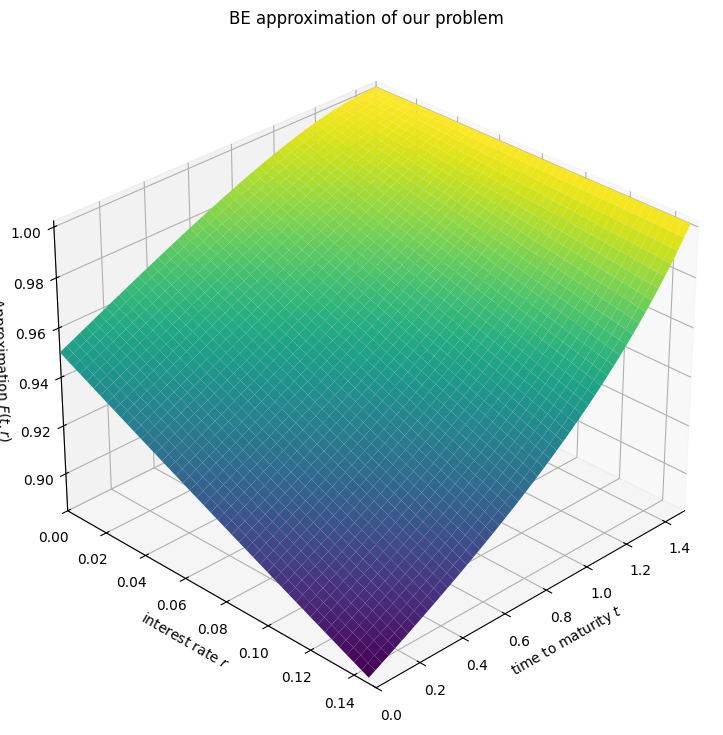

In [2]:
import matplotlib.pyplot as plt

# Surface plot function for our approximation
def ApproxPlot(F, stable, rs, ts, maxr, minr = 0,  maxt = T, mint = 0):
  """A surface plot function for our backwards euler approximation function.
  Arguments:
    F: matrix of backwards euler approximations
    stable: boolean indicating method stability
    rs: array of r values used in approximation
    ts: array of t values used in approximation
    maxr: upper r plot limit
    minr: lower r plot limit
    maxt: upper t plot limit
    mint: lower t plot limit
  Returns:
    3D Surface Plot of stock price approximations within bounds
    minr <= r <= maxr, mint <= t <= maxt
  """
  fig = plt.figure(figsize = (9,9))

  ax = plt.axes(projection='3d')

  r_idx = (rs <= maxr) & (rs >= minr)
  r_plot = rs[r_idx]

  t_idx = (ts <= maxt) & (ts >= mint)
  t_plot = ts[t_idx]

  F_plot = F[t_idx, :][:, r_idx]
  rs_grid, ts_grid = np.meshgrid(r_plot, t_plot)
  ax.set(title = "BE approximation of our problem",
         xlabel = "time to maturity $t$",
         ylabel = "interest rate $r$",
         zlabel = "Approximation $F(t,r)$",
         ylim = [minr, maxr],
         xlim = [maxt, mint])
  ax.view_init(azim=45)
  surf = ax.plot_surface(ts_grid, rs_grid, F_plot, rstride=1, cstride=1, linewidth=0, cmap='viridis')
  plt.show()

# Run our approximation function:
F, stable, rs, ts = BE_Approx(rmax, T, a, b, sigma, 50, 150)

# Input approximations and plot limits into our plot function:
ApproxPlot(F, stable, rs, ts, 0.15, 0, T, 0)

Please see `Part_3.pdf` for details of my reasoning for selecting $r_{max}$, and my choice of $N$ and $M$.